# 05 — Robustness & sensitivity analysis

A model you trust is one whose conclusions don't hinge on arbitrary knobs. Here we stress
two choices we made:

1. **Training window** — we picked 2002. Does the model's skill depend strongly on it?
2. **Host-nation advantage** — we modeled the World Cup on neutral ground. How much would a
   home-field boost for USA/Canada/Mexico change the picture?

This is the kind of check a quant runs before trusting a backtest.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

ROOT = Path.cwd()
while not (ROOT / "data" / "processed").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
FIG_DIR = ROOT / "reports" / "figures"

from src.features.build_features import build_features  # noqa: E402
from src.models.train import build_model, evaluate, FEATURES, CLASSES  # noqa: E402

matches = pd.read_csv(ROOT / "data" / "processed" / "matches_clean.csv", parse_dates=["date"])

## 1. Training-window sensitivity

We refit the selected logistic model using training data starting in different years (Elo is
always warmed on the full history) and score each on the **same** out-of-time test set
(2022+). If skill is flat across windows, our 2002 choice is safe, not lucky.

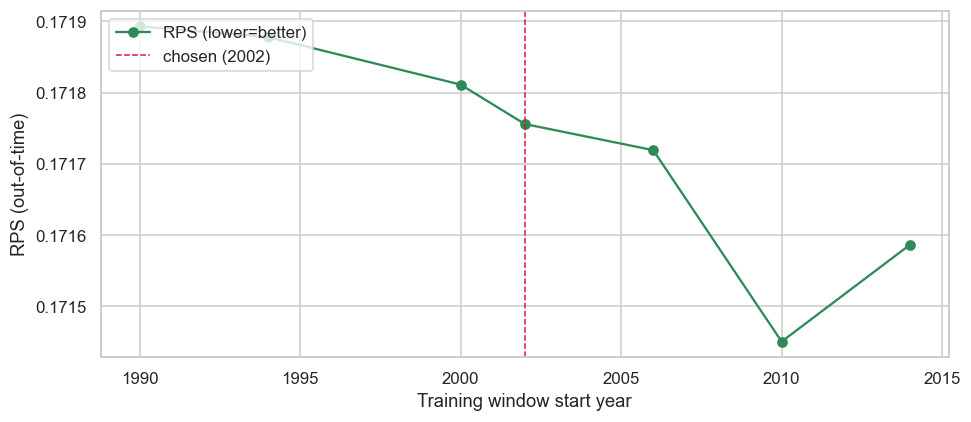

start_year,n_train,accuracy,log_loss,rps
1990,27719,0.596,0.8771,0.1719
1994,25334,0.596,0.8771,0.1719
2000,20775,0.599,0.8768,0.1718
2002,18703,0.599,0.8765,0.1718
2006,15105,0.599,0.8762,0.1717
2010,11249,0.599,0.8752,0.1715
2014,7279,0.599,0.8760,0.1716


In [2]:
rows = []
for start in [1990, 1994, 2000, 2002, 2006, 2010, 2014]:
    feats = build_features(matches, train_start_year=start)
    feats["year"] = feats["date"].dt.year
    feats["target_idx"] = feats["target"].map({c: i for i, c in enumerate(CLASSES)})
    tr = feats[feats["year"] < 2022]
    te = feats[feats["year"] >= 2022]
    model = build_model().fit(tr[FEATURES], tr["target_idx"])
    m = evaluate(f"start {start}", te["target_idx"].to_numpy(), model.predict_proba(te[FEATURES]))
    m["start_year"] = start
    m["n_train"] = len(tr)
    rows.append(m)
sens = pd.DataFrame(rows)

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(sens["start_year"], sens["rps"], "o-", color="seagreen", label="RPS (lower=better)")
ax1.axvline(2002, color="crimson", ls="--", lw=1, label="chosen (2002)")
ax1.set(xlabel="Training window start year", ylabel="RPS (out-of-time)")
ax1.legend(loc="upper left")
fig.tight_layout()
fig.savefig(FIG_DIR / "12_window_sensitivity.png", bbox_inches="tight")
plt.show()
display(sens[["start_year", "n_train", "accuracy", "log_loss", "rps"]]
        .style.format({"accuracy": "{:.3f}", "log_loss": "{:.4f}", "rps": "{:.4f}"}).hide(axis="index"))

**Takeaway:** out-of-time skill is essentially flat across windows — the model is *not*
sensitive to this knob. 2002 is a reasonable middle ground (lots of data, modern era), and
nothing material rides on the exact cutoff. That is the result we want from a robustness check.

## 2. Host-nation advantage

Our headline model treats every match as neutral. In reality the three hosts enjoy home
crowds and no travel. We re-run the simulation giving USA/Canada/Mexico an Elo boost and see
how the title odds shift. (We keep neutral as the headline to avoid overclaiming, and show
the sensitivity here.)

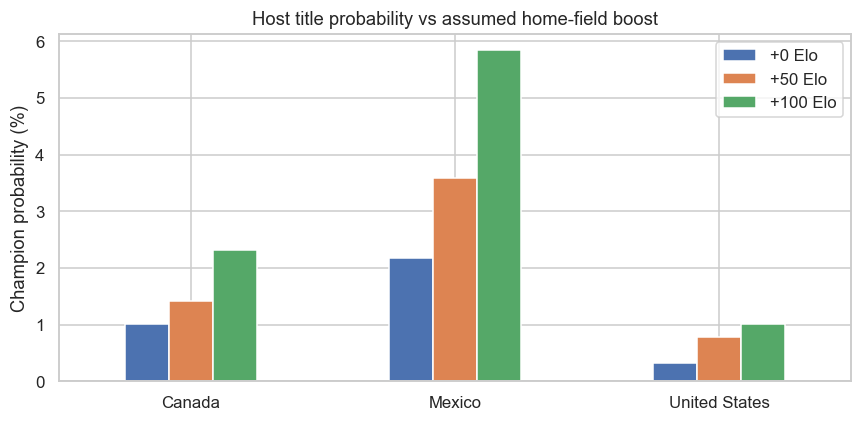

,+0 Elo,+50 Elo,+100 Elo
team,,,
Canada,1.0%,1.4%,2.3%
Mexico,2.2%,3.6%,5.8%
United States,0.3%,0.8%,1.0%


In [3]:
from src.simulation.montecarlo import run_montecarlo  # noqa: E402
from src.simulation.tournament import build_context, HOST_NATIONS  # noqa: E402

ctx = build_context()
scenarios = {f"+{b} Elo": run_montecarlo(5000, ctx=ctx, host_bonus=b) for b in (0, 50, 100)}

host_df = pd.DataFrame({
    label: df.set_index("team").loc[sorted(HOST_NATIONS), "Champion"]
    for label, df in scenarios.items()
})

fig, ax = plt.subplots(figsize=(8, 4))
host_df.mul(100).plot(kind="bar", ax=ax)
ax.set(title="Host title probability vs assumed home-field boost",
       ylabel="Champion probability (%)", xlabel="")
ax.set_xticklabels(host_df.index, rotation=0)
fig.tight_layout()
fig.savefig(FIG_DIR / "13_host_advantage.png", bbox_inches="tight")
plt.show()
display(host_df.style.format("{:.1%}"))

**Takeaway:** a plausible home-field boost lifts the hosts (especially Mexico, the strongest
of the three) by a few percentage points, but does not overturn the top of the board — Spain
and Argentina remain the favorites. The headline forecast is robust to this modeling choice.

---
### Conclusion
Both knobs we examined leave the core conclusions intact. The forecast is **stable**, which is
exactly what separates a trustworthy model from an overfit one.